In the lab, a classification tree was applied to the Carseats data set af-</br>
ter converting Sales into a qualitative response variable. Now we will</br>
seek to predict Sales using regression trees and related approaches,</br>
treating the response as a quantitative variable.</br>

(a) Split the data set into a training set and a test set.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor

from ISLP import load_data

car = load_data("Carseats")

# Response: Sales (quantitative)
y = car["Sales"]

# Drop Sales to create predictors matrix
X = car.drop(columns=["Sales"])

# Convert categorical columns to dummy variables
X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)


Training size: (320, 11)
Test size: (80, 11)


(b) Fit a regression tree to the training set. Plot the tree, and inter-</br>
pret the results. What test MSE do you obtain?</br>

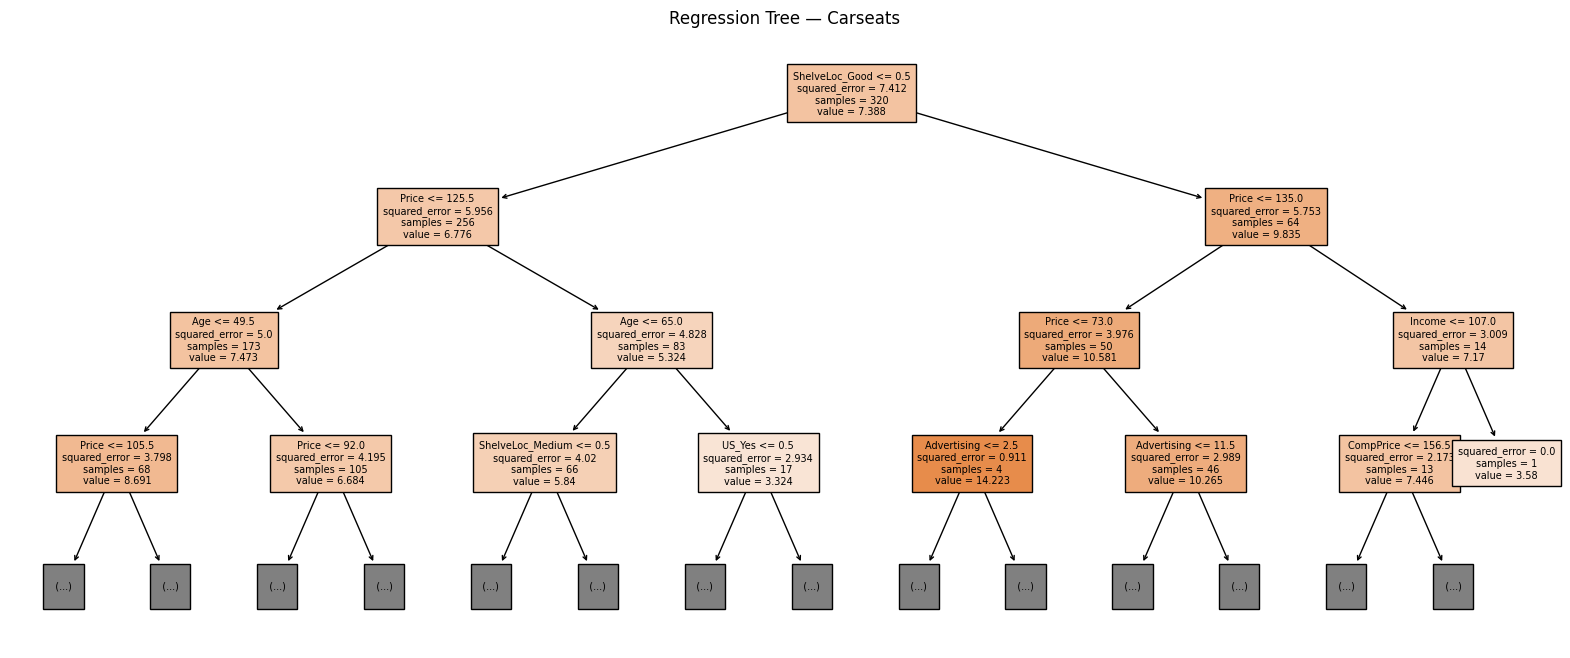

Test MSE (Regression Tree): 6.1788775000000005


In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
# Plot the tree
plt.figure(figsize=(20, 8))
plot_tree(tree_model, feature_names=X.columns, filled=True, fontsize=7, max_depth=3)
plt.title("Regression Tree — Carseats")
plt.show()

# Compute Test MSE
y_pred_tree = tree_model.predict(X_test)
tree_mse = mean_squared_error(y_test, y_pred_tree)
print("Test MSE (Regression Tree):", tree_mse)


特徵重要性 (Feature Importance):
Price               
ShelveLoc_Good      
Age                
CompPrice           
ShelveLoc_Medium    


(c) Use cross-validation in order to determine the optimal level of</br>
tree complexity. Does pruning the tree improve the test MSE?

In [13]:
path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Try all alpha values using cross-validation
tree_cv_models = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    tree_cv_models.append(mse)

best_alpha = ccp_alphas[np.argmin(tree_cv_models)]

print("Best alpha:", best_alpha)

# Fit final pruned tree
pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

# Compute test MSE
y_pred_pruned = pruned_tree.predict(X_test)
pruned_mse = mean_squared_error(y_test, y_pred_pruned)
print("Test MSE (Pruned Tree):", pruned_mse)



Best alpha: 0.0433734134615473
Test MSE (Pruned Tree): 4.892525971721255


(d) Use the bagging approach in order to analyze this data. What</br>
test MSE do you obtain? Use the feature_importance_ values to</br>
determine which variables are most important.</br>

In [6]:
bag_model = BaggingRegressor(
    base_estimator=DecisionTreeRegressor(),
    n_estimators=500,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)
bag_mse = mean_squared_error(y_test, y_pred_bag)
print("Test MSE (Bagging):", bag_mse)

# feature importance (mean of trees)
bag_importance = np.mean(
    [tree.feature_importances_ for tree in bag_model.estimators_],
    axis=0
)

bag_importance = pd.Series(bag_importance, index=X.columns).sort_values(ascending=False)
print("\nBagging Feature Importance:")
print(bag_importance.head(10))

Test MSE (Bagging): 3.0667348011850093

Bagging Feature Importance:
Price               0.314641
ShelveLoc_Good      0.197288
Age                 0.117612
CompPrice           0.094779
Advertising         0.082301
ShelveLoc_Medium    0.058032
Income              0.052911
Population          0.040303
Education           0.029735
Urban_Yes           0.006875
dtype: float64


(e) Use random forests to analyze this data. What test MSE do</br>
you obtain? Use the feature_importance_ values to determine</br>
which variables are most important. Describe the effect of m, the</br>
number of variables considered at each split, on the error rate</br>
obtained.

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_features="sqrt"  # typical default
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)

print("Test MSE (Random Forest):", rf_mse)

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\nRandom Forest Feature Importance:")
print(rf_importance.sort_values(ascending=False).head(10))

Test MSE (Random Forest): 3.7528088035900167

Random Forest Feature Importance:
Price               0.247043
ShelveLoc_Good      0.150670
Age                 0.127665
Advertising         0.102280
CompPrice           0.090889
Income              0.079364
Population          0.077194
Education           0.052545
ShelveLoc_Medium    0.045677
US_Yes              0.014467
dtype: float64


(f) Now analyze the data using BART, and report your results.

In [23]:
from sklearn.metrics import mean_squared_error
from ISLP.bart import BART
carseats = load_data("Carseats")

# 1. Load Carseats dataset
# carseats = pd.read_csv("Carseats.csv")

# 2. Separate predictors and response
X = carseats.drop(columns=['Sales'])
y = carseats['Sales']

# 3. One-hot encode categorical predictors
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Ensure numeric dtype (float64)
X = X.astype(float).values
y = y.astype(float).values

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 6. Fit BART model with explicit hyperparameters
bart = BART(
    num_trees=200,     # number of trees
    burnin=200,        # burn-in iterations
    ndraw=1000,        # posterior samples
    random_state=42,   # reproducibility
    n_jobs=-1          # use all cores
)
bart.fit(X_train, y_train)

# 7. Predict on test set
y_pred_bart = bart.predict(X_test)

# 8. Compute test MSE
test_mse_bart = mean_squared_error(y_test, y_pred_bart)
print("Test MSE (BART):", test_mse_bart)

Test MSE (BART): 1.2368714218902683


BART (Bayesian Additive Regression Trees)